In [2]:

import os
import re
import json
import random
from typing import List, Dict, Tuple
from collections import Counter
import chardet

# ML imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pickle

class TranscriptPreprocessor:
    def __init__(self, transcripts_dir: str, processed_dir: str):
        self.transcripts_dir = transcripts_dir
        self.processed_dir = processed_dir
        self.intents = set()
        self.slot_types = set()
        self.medical_keywords = {
            'SYMPTOM': ['pain', 'cough', 'breathless', 'itching', 'nausea', 'vomiting', 'fever',
                        'headache', 'dizziness', 'fatigue', 'swelling', 'rash', 'discharge',
                        'bleeding', 'numbness', 'tingling', 'weakness', 'stiffness'],
            'LOCATION': ['chest', 'abdomen', 'back', 'head', 'neck', 'arm', 'leg', 'knee',
                         'shoulder', 'hip', 'ankle', 'wrist', 'upper', 'lower', 'left', 'right'],
            'DURATION': ['days', 'weeks', 'months', 'years', 'hours', 'minutes', 'ago',
                         'since', 'yesterday', 'morning', 'evening', 'night', 'recently'],
            'SEVERITY': ['severe', 'mild', 'moderate', 'intense', 'slight', 'terrible',
                         'bad', 'worse', 'better', 'improved'],
            'PROGRESSION': ['getting worse', 'improving', 'constant', 'intermittent',
                            'comes and goes', 'fluctuates', 'stable'],
            'MEDICATION': ['ibuprofen', 'paracetamol', 'aspirin', 'antacid', 'antibiotic',
                           'inhaler', 'cream', 'ointment', 'tablet', 'pill'],
            'HISTORY': ['diabetes', 'hypertension', 'asthma', 'allergy', 'surgery',
                        'family history', 'previous', 'diagnosed']
        }
        os.makedirs(processed_dir, exist_ok=True)

    def load_transcripts(self) -> List[Dict]:
        transcripts = []
        for filename in os.listdir(self.transcripts_dir):
            if filename.endswith('.txt'):
                filepath = os.path.join(self.transcripts_dir, filename)
                category = filename[:3]
                transcript_id = filename[:-4]
                with open(filepath, 'rb') as f:
                    encoding = chardet.detect(f.read())['encoding'] or 'utf-8'
                with open(filepath, 'r', encoding=encoding, errors='ignore') as f:
                    content = f.read()
                transcripts.append({'id': transcript_id, 'category': category, 'content': content, 'filepath': filepath})
        return transcripts

    def parse_turns(self, content: str) -> List[Dict]:
        turns = []
        for line in content.strip().split('\n'):
            line = line.strip()
            if not line:
                continue
            if line.startswith('D:'):
                turns.append({'speaker': 'Doctor', 'text': line[2:].strip()})
            elif line.startswith('P:'):
                turns.append({'speaker': 'Patient', 'text': line[2:].strip()})
        return turns

    def normalize_text(self, text: str) -> str:
        return re.sub(r'\s+', ' ', text.lower().strip())

    def tokenize(self, text: str) -> List[str]:
        return re.sub(r'([?.!,;])', r' \1 ', text).split()

    def infer_intent(self, speaker: str, text: str) -> str:
        t = text.lower()
        if speaker == 'Doctor':
            if any(q in t for q in ['what', 'when', 'where', 'how', 'which', 'who']):
                if 'symptom' in t or 'feel' in t or 'problem' in t:
                    return 'Ask_Symptom'
                elif any(word in t for word in ['long', 'when', 'start', 'began']):
                    return 'Ask_Duration'
                elif 'where' in t or 'location' in t:
                    return 'Ask_Location'
                elif any(word in t for word in ['severe', 'bad', 'intense']):
                    return 'Ask_Severity'
                elif 'medication' in t or 'medicine' in t or 'taking' in t:
                    return 'Ask_Medication'
                elif 'history' in t or 'before' in t or 'previous' in t:
                    return 'Ask_History'
                else:
                    return 'Ask_General'
            elif any(word in t for word in ['test', 'examine', 'check']):
                return 'Propose_Examination'
            elif any(word in t for word in ['prescribe', 'recommend', 'suggest']):
                return 'Provide_Treatment'
            return 'Doctor_Other'
        else:
            for slot, keywords in self.medical_keywords.items():
                if any(word in t for word in keywords):
                    return f'Provide_{slot.capitalize()}'
            return 'Patient_Other'

    def extract_slots(self, text: str) -> List[Dict]:
        t = text.lower()
        entities = []
        for slot_type, keywords in self.medical_keywords.items():
            for kw in keywords:
                for match in re.finditer(rf'\b{re.escape(kw)}\w*\b', t):
                    entities.append({'type': slot_type, 'text': match.group(), 'start': match.start(), 'end': match.end()})
        entities.sort(key=lambda x: x['start'])
        non_overlap = []
        for e in entities:
            if not non_overlap or e['start'] >= non_overlap[-1]['end']:
                non_overlap.append(e)
        return non_overlap

    def tokens_to_bio(self, tokens: List[str], text: str, entities: List[Dict]) -> List[str]:
        bio = ['O'] * len(tokens)
        char_to_token = []
        pos = 0
        text_lower = text.lower()
        for i, token in enumerate(tokens):
            start = text_lower.find(token, pos)
            start = start if start != -1 else pos
            end = start + len(token)
            char_to_token.append((start, end, i))
            pos = end
        for e in entities:
            overlap = [i for s, en, i in char_to_token if s < e['end'] and en > e['start']]
            if overlap:
                bio[overlap[0]] = f'B-{e["type"]}'
                for idx in overlap[1:]:
                    bio[idx] = f'I-{e["type"]}'
        return bio

    def process_transcripts(self) -> List[Dict]:
        data = []
        for t in self.load_transcripts():
            for idx, turn in enumerate(self.parse_turns(t['content'])):
                text = turn['text']
                norm_text = self.normalize_text(text)
                tokens = self.tokenize(norm_text)
                intent = self.infer_intent(turn['speaker'], text)
                self.intents.add(intent)
                entities = self.extract_slots(norm_text)
                self.slot_types.update([e['type'] for e in entities])
                bio_tags = self.tokens_to_bio(tokens, norm_text, entities)
                data.append({'transcript_id': t['id'], 'category': t['category'], 'turn_id': idx,
                             'speaker': turn['speaker'], 'original_text': text, 'normalized_text': norm_text,
                             'tokens': tokens, 'intent': intent, 'entities': entities, 'bio_tags': bio_tags})
        return data

    def create_splits(self, data: List[Dict], train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42) -> Tuple[List[Dict], List[Dict], List[Dict]]:
        ids = list({item['transcript_id'] for item in data})
        random.seed(seed)
        random.shuffle(ids)
        n_train = int(len(ids) * train_ratio)
        n_val = int(len(ids) * val_ratio)
        train_ids, val_ids, test_ids = set(ids[:n_train]), set(ids[n_train:n_train+n_val]), set(ids[n_train+n_val:])
        train_data = [x for x in data if x['transcript_id'] in train_ids]
        val_data = [x for x in data if x['transcript_id'] in val_ids]
        test_data = [x for x in data if x['transcript_id'] in test_ids]
        return train_data, val_data, test_data

    def save_processed_data(self, train_data: List[Dict], val_data: List[Dict], test_data: List[Dict]):
        for name, d in zip(['train', 'val', 'test'], [train_data, val_data, test_data]):
            with open(os.path.join(self.processed_dir, f'{name}.json'), 'w') as f:
                json.dump(d, f, indent=2)
        metadata = {'intents': sorted(list(self.intents)),
                    'slots': ['O'] + [f'{p}-{s}' for s in sorted(self.slot_types) for p in ['B', 'I']],
                    'num_intents': len(self.intents),
                    'num_slots': len(self.slot_types)+1,
                    'train_size': len(train_data),
                    'val_size': len(val_data),
                    'test_size': len(test_data)}
        with open(os.path.join(self.processed_dir, 'metadata.json'), 'w') as f:
            json.dump(metadata, f, indent=2)
        return metadata

    def get_statistics(self, data: List[Dict]) -> Dict:
        return {
            'num_utterances': len(data),
            'num_transcripts': len(set([x['transcript_id'] for x in data])),
            'intent_distribution': Counter([x['intent'] for x in data]),
            'category_distribution': Counter([x['category'] for x in data]),
            'speaker_distribution': Counter([x['speaker'] for x in data]),
            'avg_tokens_per_utterance': sum(len(x['tokens']) for x in data)/len(data) if data else 0,
            'slot_type_counts': Counter([e['type'] for x in data for e in x['entities']])
        }


class RuleBasedSlotExtractor:
    """Extracts medical-related slots from text using keywords and regex patterns."""
    def __init__(self):
        self.medical_keywords = {
            'SYMPTOM': ['pain', 'cough', 'breathless', 'itching', 'nausea', 'vomiting', 'fever', 'headache', 
                        'dizziness', 'fatigue', 'swelling', 'rash', 'discharge', 'bleeding', 'numbness', 
                        'tingling', 'weakness', 'stiffness', 'ache', 'sore', 'hurt'],
            'LOCATION': ['chest', 'abdomen', 'back', 'head', 'neck', 'arm', 'leg', 'knee', 'shoulder', 
                         'hip', 'ankle', 'wrist', 'upper', 'lower', 'left', 'right', 'stomach', 'belly', 
                         'throat', 'nose', 'ear', 'eye'],
            'DURATION': ['days', 'weeks', 'months', 'years', 'hours', 'minutes', 'ago', 'since', 
                         'yesterday', 'morning', 'evening', 'night', 'recently', 'today', 'last', 'past', 'now'],
            'SEVERITY': ['severe', 'mild', 'moderate', 'intense', 'slight', 'terrible', 'bad', 'worse', 
                         'better', 'improved', 'serious', 'sharp', 'dull'],
            'PROGRESSION': ['getting worse', 'improving', 'constant', 'intermittent', 'comes and goes', 
                            'fluctuates', 'stable', 'gradually', 'suddenly'],
            'MEDICATION': ['ibuprofen', 'paracetamol', 'aspirin', 'antacid', 'antibiotic', 'inhaler', 
                           'cream', 'ointment', 'tablet', 'pill', 'medicine', 'drug'],
            'HISTORY': ['diabetes', 'hypertension', 'asthma', 'allergy', 'surgery', 'family history', 
                        'previous', 'diagnosed', 'condition']
        }

        self.patterns = {
            'DURATION': [
                r'\b(\d+)\s+(day|week|month|year|hour|minute)s?\b',
                r'\b(yesterday|today|recently|last\s+\w+)\b',
                r'\bsince\s+(\w+)\b',
                r'\b(\w+)\s+ago\b'
            ],
            'SEVERITY': [
                r'\b(very|extremely|really|quite)\s+(severe|bad|intense|painful)\b',
                r'\b(mild|moderate|severe|intense)\b'
            ],
            'LOCATION': [
                r'\b(upper|lower|left|right)\s+(abdomen|chest|back|arm|leg)\b',
                r'\bin\s+(my|the)\s+(\w+)\b'
            ]
        }

    def extract_slots(self, text: str, tokens: List[str]) -> List[str]:
        """Returns BIO-tagged slots for a tokenized text."""
        text_lower = text.lower()
        bio_tags = ['O'] * len(tokens)

        # Map character indices to token indices
        char_to_token = []
        pos = 0
        for i, token in enumerate(tokens):
            start = text_lower.find(token.lower(), pos)
            start = pos if start == -1 else start
            end = start + len(token)
            char_to_token.append((start, end, i))
            pos = end

        # Detect keyword-based entities
        entities = []
        for slot, keywords in self.medical_keywords.items():
            for kw in keywords:
                pattern = r'\b' + re.escape(kw) + r'\w*\b'
                entities.extend({'type': slot, 'start': m.start(), 'end': m.end()} 
                                for m in re.finditer(pattern, text_lower))

        # Detect regex-based patterns
        for slot, patterns in self.patterns.items():
            for pattern in patterns:
                entities.extend({'type': slot, 'start': m.start(), 'end': m.end()} 
                                for m in re.finditer(pattern, text_lower))

        # Remove overlapping entities
        entities.sort(key=lambda x: x['start'])
        non_overlap = []
        for ent in entities:
            if not non_overlap or ent['start'] >= non_overlap[-1]['end']:
                non_overlap.append(ent)

        # Assign BIO tags
        for ent in non_overlap:
            overlapping_tokens = [idx for start, end, idx in char_to_token 
                                  if start < ent['end'] and end > ent['start']]
            if overlapping_tokens:
                bio_tags[overlapping_tokens[0]] = f'B-{ent["type"]}'
                for idx in overlapping_tokens[1:]:
                    bio_tags[idx] = f'I-{ent["type"]}'

        return bio_tags


class IntentClassifier:
    """Classifies text intents using TF-IDF features and either Logistic Regression or SVM."""
    def __init__(self, model_type='logistic'):
        self.model_type = model_type
        self.vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=2)

        self.classifier = (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
                           if model_type == 'logistic' 
                           else SVC(kernel='rbf', gamma='scale', class_weight='balanced', random_state=42))

        self.intent2id = {}
        self.id2intent = {}

    def fit(self, texts: List[str], intents: List[str]):
        """Train the classifier on text-intent pairs."""
        unique_intents = sorted(set(intents))
        self.intent2id = {intent: idx for idx, intent in enumerate(unique_intents)}
        self.id2intent = {idx: intent for intent, idx in self.intent2id.items()}
        X = self.vectorizer.fit_transform(texts)
        y = [self.intent2id[i] for i in intents]
        self.classifier.fit(X, y)

    def predict(self, texts: List[str]) -> List[str]:
        X = self.vectorizer.transform(texts)
        return [self.id2intent[pred] for pred in self.classifier.predict(X)]

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({
                'vectorizer': self.vectorizer,
                'classifier': self.classifier,
                'intent2id': self.intent2id,
                'id2intent': self.id2intent,
                'model_type': self.model_type
            }, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.vectorizer = data['vectorizer']
        self.classifier = data['classifier']
        self.intent2id = data['intent2id']
        self.id2intent = data['id2intent']
        self.model_type = data['model_type']


class RuleBasedSLU:
    """End-to-end SLU system combining rule-based slot extraction with ML intent classification."""
    def __init__(self, model_type='logistic'):
        self.slot_extractor = RuleBasedSlotExtractor()
        self.intent_classifier = IntentClassifier(model_type)

    def train(self, train_data: List[Dict]):
        texts = [d['normalized_text'] for d in train_data]
        intents = [d['intent'] for d in train_data]
        self.intent_classifier.fit(texts, intents)

    def predict(self, data: List[Dict]) -> Tuple[List[str], List[List[str]]]:
        predicted_intents = self.intent_classifier.predict([d['normalized_text'] for d in data])
        predicted_slots = [self.slot_extractor.extract_slots(d['normalized_text'], d['tokens']) 
                           for d in data]
        return predicted_intents, predicted_slots

    def save(self, path: str):
        self.intent_classifier.save(path)

    def load(self, path: str):
        self.intent_classifier.load(path)



def load_data(path: str) -> List[Dict]:
    with open(path, 'r') as f:
        return json.load(f)

TRANSCRIPTS_DIR = 'data/transcripts'  # for preprocessing
PROCESSED_DIR = 'data/processed'

preprocessor = TranscriptPreprocessor(transcripts_dir=TRANSCRIPTS_DIR, processed_dir=PROCESSED_DIR)

data = preprocessor.process_transcripts()
train_data, val_data, test_data = preprocessor.create_splits(data)
metadata = preprocessor.save_processed_data(train_data, val_data, test_data)
stats = preprocessor.get_statistics(train_data)
print(f"Processed {len(data)} utterances, {len(preprocessor.intents)} intents, {len(preprocessor.slot_types)} slots")
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Average tokens per utterance: {stats['avg_tokens_per_utterance']:.2f}")

train_data = load_data(os.path.join(PROCESSED_DIR, 'train.json'))
val_data = load_data(os.path.join(PROCESSED_DIR, 'val.json'))
test_data = load_data(os.path.join(PROCESSED_DIR, 'test.json'))

slu_model = RuleBasedSLU(model_type='logistic')
print("Training Rule-Based SLU (intent classifier)...")
slu_model.train(train_data)

print("Evaluating on validation set...")
val_intents, val_slots = slu_model.predict(val_data)
true_val_intents = [d['intent'] for d in val_data]
print(f"Validation Intent Accuracy: {accuracy_score(true_val_intents, val_intents):.4f}")
print(classification_report(true_val_intents, val_intents, zero_division=0))

# Save model
os.makedirs(PROCESSED_DIR, exist_ok=True)
slu_model.save(os.path.join(PROCESSED_DIR, 'rule_baseline_model.pkl'))

print("Evaluating on test set...")
test_intents, test_slots = slu_model.predict(test_data)
true_test_intents = [d['intent'] for d in test_data]
print(f"Test Intent Accuracy: {accuracy_score(true_test_intents, test_intents):.4f}")
print(classification_report(true_test_intents, test_intents, zero_division=0))

for i in range(min(5, len(test_data))):
    item = test_data[i]
    print('-'*80)
    print(f"Transcript: {item.get('transcript_id')}  Turn: {item.get('turn_id')}  Speaker: {item.get('speaker')}")
    print('Original:', item.get('original_text'))
    print('Normalized:', item.get('normalized_text'))
    print('Tokens:', item.get('tokens'))
    pred_intent, pred_slots = slu_model.predict([item])
    print('Gold intent:', item.get('intent'))
    print('Pred intent:', pred_intent[0])
    print('Gold BIO:', item.get('bio_tags'))
    print('Pred BIO (slot extractor):', pred_slots[0])


with open(os.path.join(PROCESSED_DIR, 'metadata_after_training.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts saved to', PROCESSED_DIR)


Processed 26604 utterances, 18 intents, 7 slots
Train: 18813, Val: 3715, Test: 4076
Average tokens per utterance: 15.89
Training Rule-Based SLU (intent classifier)...
Evaluating on validation set...
Validation Intent Accuracy: 0.8339
                     precision    recall  f1-score   support

       Ask_Duration       0.87      0.83      0.85       132
        Ask_General       0.92      0.89      0.90       266
        Ask_History       0.37      0.88      0.52         8
       Ask_Location       0.82      0.89      0.85        63
     Ask_Medication       0.23      1.00      0.38         3
       Ask_Severity       0.75      0.67      0.71         9
        Ask_Symptom       0.56      0.80      0.66        59
       Doctor_Other       0.96      0.87      0.91      1302
      Patient_Other       0.95      0.82      0.88      1237
Propose_Examination       0.36      0.71      0.48        17
   Provide_Duration       0.64      0.84      0.72       159
    Provide_History       0.37   

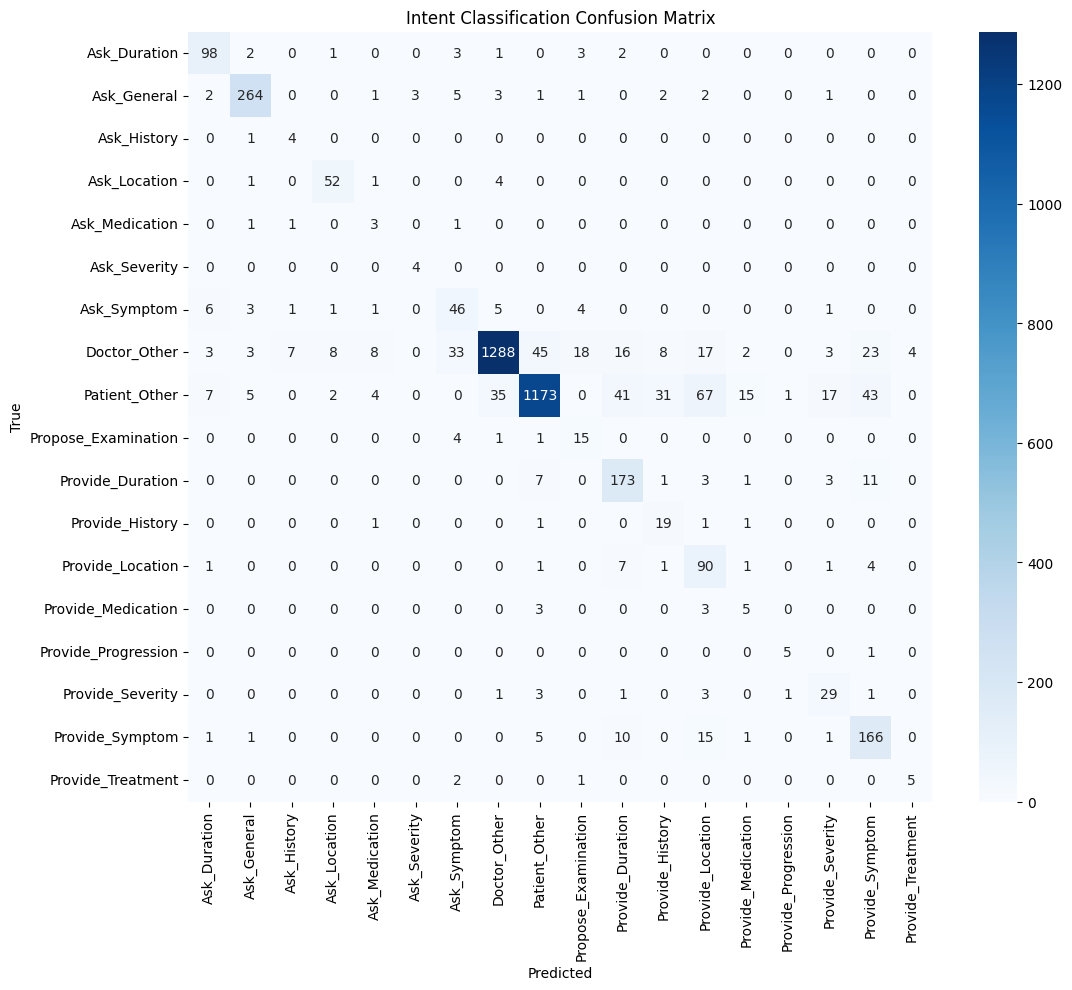

Intent Classification Report:
                     precision    recall  f1-score   support

       Ask_Duration       0.83      0.89      0.86       110
        Ask_General       0.94      0.93      0.93       285
        Ask_History       0.31      0.80      0.44         5
       Ask_Location       0.81      0.90      0.85        58
     Ask_Medication       0.16      0.50      0.24         6
       Ask_Severity       0.57      1.00      0.73         4
        Ask_Symptom       0.49      0.68      0.57        68
       Doctor_Other       0.96      0.87      0.91      1486
      Patient_Other       0.95      0.81      0.88      1441
Propose_Examination       0.36      0.71      0.48        21
   Provide_Duration       0.69      0.87      0.77       199
    Provide_History       0.31      0.83      0.45        23
   Provide_Location       0.45      0.85      0.59       106
 Provide_Medication       0.19      0.45      0.27        11
Provide_Progression       0.71      0.83      0.77    

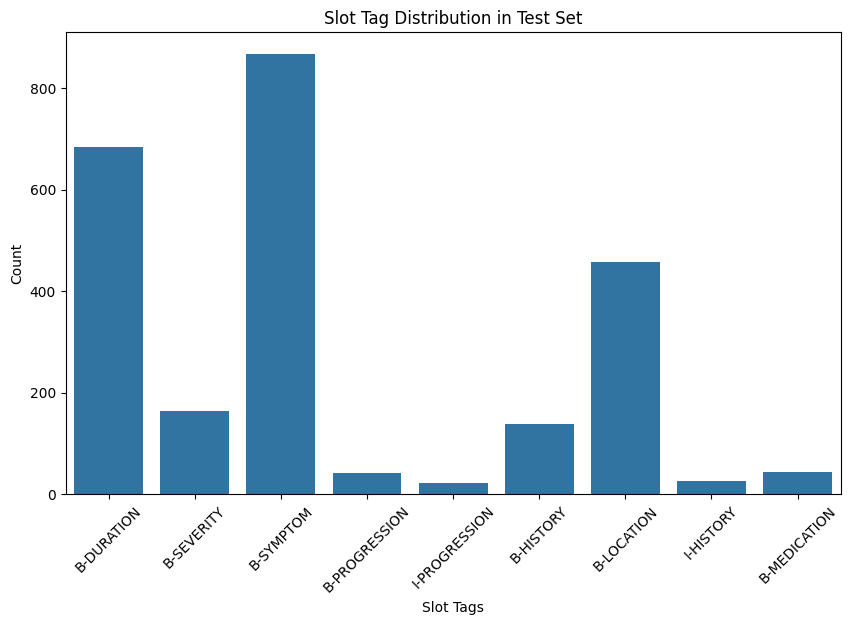

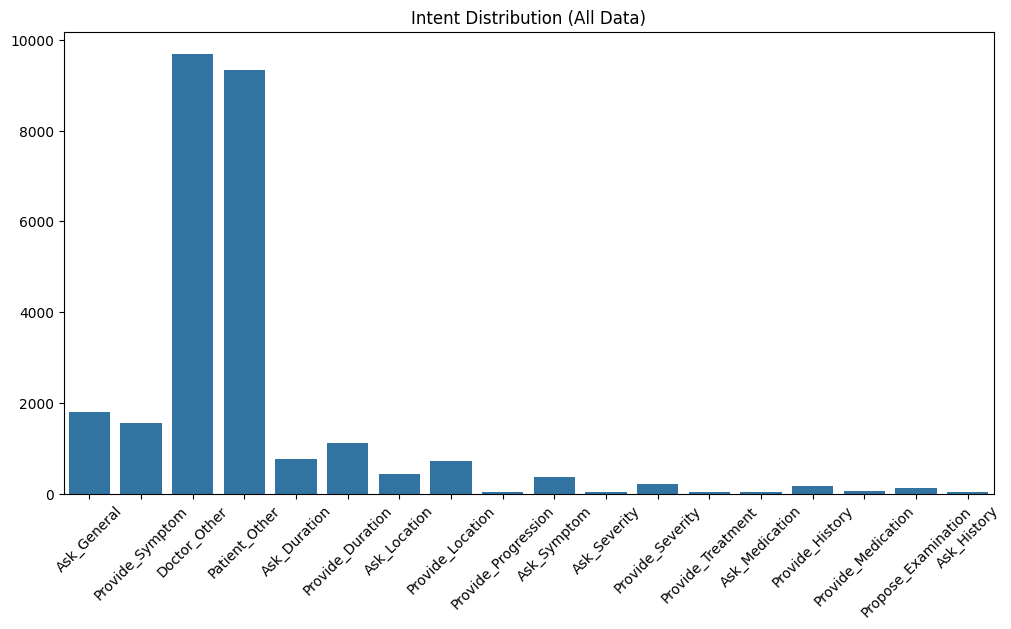

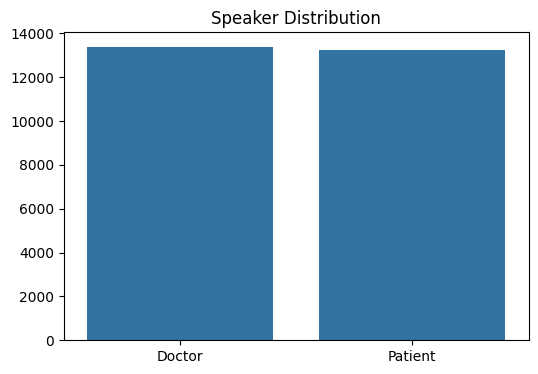

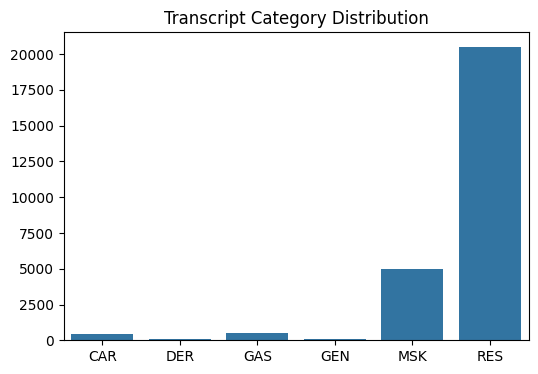

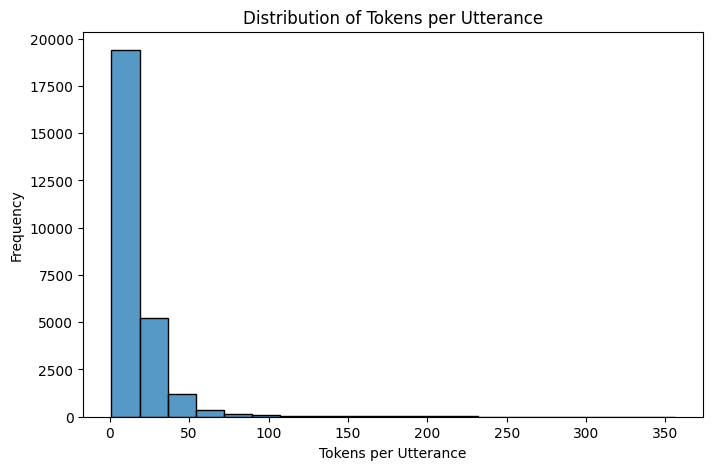

,Transcript,Turn,Speaker,Text,Gold Intent,Pred Intent,Gold Slots,Pred Slots
0,GAS0004,0,Doctor,i understand that you've been having some diar...,Doctor_Other,Doctor_Other,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,GAS0004,1,Patient,"yeah, sure i had, i've been having diarrhea fo...",Provide_Duration,Provide_Duration,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, B-DURATIO..."
2,GAS0004,2,Doctor,"ok, i'm sorry to hear that. uh, have you ever ...",Doctor_Other,Doctor_Other,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
3,GAS0004,3,Patient,"um, have i experienced something like this bef...",Patient_Other,Patient_Other,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
4,GAS0004,4,Doctor,"ok. and over the three or four days, have your...",Doctor_Other,Doctor_Other,"[O, O, O, O, O, O, O, O, B-DURATION, O, O, O, ...","[O, O, O, O, O, O, O, O, B-DURATION, O, O, O, ..."
5,GAS0004,5,Patient,i think they've mostly been loose. i think the...,Patient_Other,Provide_Duration,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
6,GAS0004,6,Doctor,"ok, and how many times a day have you been hav...",Ask_General,Ask_General,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
7,GAS0004,7,Patient,"oh my god, i have i've lost count. i'm going e...",Patient_Other,Provide_Duration,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
8,GAS0004,8,Doctor,"ok, every hour. ok, and then you notice any ch...",Doctor_Other,Doctor_Other,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-LOCA..."
9,GAS0004,9,Patient,"no, it's brown.",Patient_Other,Patient_Other,"[O, O, O, O, O]","[O, O, O, O, O]"


In [3]:
# Cell 1: Intent Classification Metrics and Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# True and predicted intents for test set
y_true = [d['intent'] for d in test_data]
y_pred = test_intents
intent_labels = sorted(list(preprocessor.intents))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=intent_labels)
cmd = ConfusionMatrixDisplay(cm, display_labels=intent_labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=intent_labels, yticklabels=intent_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Intent Classification Confusion Matrix')
plt.show()

# Classification report
print("Intent Classification Report:")
print(classification_report(y_true, y_pred, zero_division=0))


# Cell 2: Slot Extraction Metrics (token-level)
from seqeval.metrics import classification_report as seq_classification_report, f1_score as seq_f1_score

# Convert list of BIO tags to the format seqeval expects
true_slots = [d['bio_tags'] for d in test_data]
pred_slots = test_slots

print("Slot Extraction Report (token-level BIO):")
print(seq_classification_report(true_slots, pred_slots, zero_division=0))
print("Overall Slot F1-score:", seq_f1_score(true_slots, pred_slots))


# Cell 3: Slot Distribution Visualization
slot_counts = Counter([tag for seq in true_slots for tag in seq if tag != 'O'])
plt.figure(figsize=(10,6))
sns.barplot(x=list(slot_counts.keys()), y=list(slot_counts.values()))
plt.xticks(rotation=45)
plt.title('Slot Tag Distribution in Test Set')
plt.ylabel('Count')
plt.xlabel('Slot Tags')
plt.show()


# Cell 4: Data Statistics Visualizations
# Intent distribution
intent_counts = Counter([d['intent'] for d in data])
plt.figure(figsize=(12,6))
sns.barplot(x=list(intent_counts.keys()), y=list(intent_counts.values()))
plt.xticks(rotation=45)
plt.title('Intent Distribution (All Data)')
plt.show()

# Speaker distribution
speaker_counts = Counter([d['speaker'] for d in data])
plt.figure(figsize=(6,4))
sns.barplot(x=list(speaker_counts.keys()), y=list(speaker_counts.values()))
plt.title('Speaker Distribution')
plt.show()

# Category distribution
category_counts = Counter([d['category'] for d in data])
plt.figure(figsize=(6,4))
sns.barplot(x=list(category_counts.keys()), y=list(category_counts.values()))
plt.title('Transcript Category Distribution')
plt.show()

# Avg tokens per utterance histogram
token_lengths = [len(d['tokens']) for d in data]
plt.figure(figsize=(8,5))
sns.histplot(token_lengths, bins=20)
plt.xlabel('Tokens per Utterance')
plt.ylabel('Frequency')
plt.title('Distribution of Tokens per Utterance')
plt.show()


# Cell 5: Example Predictions Table
example_df = pd.DataFrame([{
    'Transcript': d['transcript_id'],
    'Turn': d['turn_id'],
    'Speaker': d['speaker'],
    'Text': d['normalized_text'],
    'Gold Intent': d['intent'],
    'Pred Intent': pred,
    'Gold Slots': d['bio_tags'],
    'Pred Slots': ps
} for d, pred, ps in zip(test_data[:10], test_intents[:10], test_slots[:10])])

example_df


In [6]:
import os
import re
import chardet
from collections import Counter

# Slot and intent extractor (using your rule-based logic)
class RuleBasedSummaryExtractor:
    def __init__(self):
        self.medical_keywords = {
            'SYMPTOM': ['pain', 'cough', 'breathless', 'itching', 'nausea', 'vomiting', 'fever',
                        'headache', 'dizziness', 'fatigue', 'swelling', 'rash', 'discharge',
                        'bleeding', 'numbness', 'tingling', 'weakness', 'stiffness'],
            'LOCATION': ['chest', 'abdomen', 'back', 'head', 'neck', 'arm', 'leg', 'knee',
                        'shoulder', 'hip', 'ankle', 'wrist', 'upper', 'lower', 'left', 'right'],
            'DURATION': ['days', 'weeks', 'months', 'years', 'hours', 'minutes', 'ago',
                        'since', 'yesterday', 'morning', 'evening', 'night', 'recently'],
            'SEVERITY': ['severe', 'mild', 'moderate', 'intense', 'slight', 'terrible',
                        'bad', 'worse', 'better', 'improved'],
            'PROGRESSION': ['getting worse', 'improving', 'constant', 'intermittent',
                            'comes and goes', 'fluctuates', 'stable'],
            'MEDICATION': ['ibuprofen', 'paracetamol', 'aspirin', 'antacid', 'antibiotic',
                           'inhaler', 'cream', 'ointment', 'tablet', 'pill'],
            'HISTORY': ['diabetes', 'hypertension', 'asthma', 'allergy', 'surgery',
                        'family history', 'previous', 'diagnosed']
        }

    def parse_turns(self, content):
        turns = []
        for line in content.strip().split('\n'):
            line = line.strip()
            if line.startswith('D:'):
                turns.append({'speaker': 'Doctor', 'text': line[2:].strip()})
            elif line.startswith('P:'):
                turns.append({'speaker': 'Patient', 'text': line[2:].strip()})
        return turns

    def get_category(self, filename):
        # assumes <category>_filename.txt
        return filename.split('_')[0] if '_' in filename else filename[:3]

    def infer_intent(self, speaker, text):
        t = text.lower()
        if speaker == 'Doctor':
            if any(q in t for q in ['what', 'when', 'where', 'how', 'which', 'who']):
                if 'symptom' in t or 'feel' in t or 'problem' in t:
                    return 'Ask_Symptom'
                elif any(word in t for word in ['long', 'when', 'start', 'began']):
                    return 'Ask_Duration'
                elif 'where' in t or 'location' in t:
                    return 'Ask_Location'
                elif any(word in t for word in ['severe', 'bad', 'intense']):
                    return 'Ask_Severity'
                elif 'medication' in t or 'medicine' in t or 'taking' in t:
                    return 'Ask_Medication'
                elif 'history' in t or 'before' in t or 'previous' in t:
                    return 'Ask_History'
                else:
                    return 'Ask_General'
            elif any(word in t for word in ['test', 'examine', 'check']):
                return 'Propose_Examination'
            elif any(word in t for word in ['prescribe', 'recommend', 'suggest']):
                return 'Provide_Treatment'
            return 'Doctor_Other'
        else:
            for slot, keywords in self.medical_keywords.items():
                if any(word in t for word in keywords):
                    return f'Provide_{slot.capitalize()}'
            return 'Patient_Other'

    def extract_keywords(self, text, slot_type):
        kw_list = self.medical_keywords.get(slot_type.upper(), [])
        text_lower = text.lower()
        results = [kw for kw in kw_list if kw in text_lower]
        return results

    def extract_main(self, turns, slot_type):
        # find first patient utterance mentioning keywords
        for turn in turns:
            if turn['speaker'] == 'Patient':
                result = self.extract_keywords(turn['text'], slot_type)
                if result:
                    if slot_type == 'DURATION':
                        # get context string or whole phrase
                        match = re.search(r"(for|since|about)?\s?(\d+\s+(week|month|day|year)s?)", turn['text'].lower())
                        return match.group(2) if match else result[0]
                    else:
                        return result[0]
        return None

    def extract_progression(self, turns):
        for turn in turns:
            if turn['speaker'] == 'Patient':
                prog_keywords = self.medical_keywords['PROGRESSION']
                for phrase in prog_keywords:
                    if phrase in turn['text'].lower():
                        return phrase
        return None

    def extract_severity(self, turns):
        sev_keywords = self.medical_keywords['SEVERITY']
        for turn in turns:
            if turn['speaker'] == 'Patient':
                for word in sev_keywords:
                    if word in turn['text'].lower():
                        return word
        return None

    def extract_example_utterance(self, turns, maxlen=70):
        pts = [t['text'] for t in turns if t['speaker'] == 'Patient' and len(t['text'].strip()) > 5]
        if pts:
            utter = pts[0]
            if len(utter) > maxlen:
                return utter[:maxlen-3] + "..."
            return utter
        return ''


    def summarize(self, file_path):
        filename = os.path.basename(file_path)
        with open(file_path, 'rb') as f:
            encoding = chardet.detect(f.read())['encoding'] or 'utf-8'
        with open(file_path, 'r', encoding=encoding, errors='ignore') as f:
            content = f.read()
        turns = self.parse_turns(content)
        category = self.get_category(filename)
        transcript_id = filename[:-4]
        utterances = [turn['text'] for turn in turns]
        intents = [self.infer_intent(turn['speaker'], turn['text']) for turn in turns]
        intent_count = dict(Counter(intents))

        # Structured summary
        summary = {
            'category': category,
            'example_utterance': self.extract_example_utterance(turns),
            'intents_count': intent_count,
            'main_duration': self.extract_main(turns, 'DURATION'),
            'main_location': self.extract_main(turns, 'LOCATION'),
            'num_turns': len(turns),
            'progression': self.extract_progression(turns),
            'severity': self.extract_severity(turns),
            'top_symptoms': self.extract_keywords(' '.join(utterances), 'SYMPTOM'),
            'transcript_id': transcript_id
        }
        out = {
            'file': filename,
            'transcript_summaries': [summary]
        }
        return out

# USAGE: main script
def main(txt_file_path):
    extractor = RuleBasedSummaryExtractor()
    result = extractor.summarize(txt_file_path)
    import json
    print(json.dumps(result, indent=2))

# Example usage
if __name__ == '__main__':
    # Suppose you want to process "sample_input.txt"
    txt_file_path = 'sample_input.txt'
    main(txt_file_path)


{
  "file": "sample_input.txt",
  "transcript_summaries": [
    {
      "category": "sample",
      "example_utterance": "I've had this pain in my back thats kind of like in my lower back a...",
      "intents_count": {
        "Ask_General": 3,
        "Provide_Symptom": 3,
        "Ask_Duration": 1,
        "Patient_Other": 3,
        "Doctor_Other": 4,
        "Provide_Severity": 2,
        "Ask_Location": 1,
        "Provide_Location": 1
      },
      "main_duration": null,
      "main_location": "back",
      "num_turns": 18,
      "progression": "getting worse",
      "severity": "worse",
      "top_symptoms": [
        "pain",
        "numbness",
        "tingling"
      ],
      "transcript_id": "sample_input"
    }
  ]
}
